# The rattly test mass: a motion-robust OPD pipeline

A released test mass is a nearly free harmonic oscillator (a few Hz). When it
rings **cleanly** (smooth pendulum swing) the standard frequency-modulation OPD
estimate is unaffected, however large the swing. When it rings **rattly**
(impulsive, repeatedly re-excited) its broadband spectral tail reaches the
demodulation band around `f_mod` and, amplified by `nu0 / delta_nu_pk ~ 1e6`,
floods the tone and biases the standard estimate high.

This notebook accompanies the note `docs/notes/1.1_RattlyTestMass`. It

1. quantifies the in-band amplification factor,
2. shows the effect on FM1 Day09 released data (clean R1 vs rattly R2),
3. runs the **standard** and the new **robust** pipeline on every Day09 file
   (before/after), and
4. validates on synthetic data with a **known** OPD that the robust estimator
   recovers the truth where the standard one is biased high.

The robust estimator (`estimate_opd_robust` /
`het_ifo_opd.estimators.demodulate_robust`) uses: an absolute near-tone
contamination floor and reliability flag, a matched-filter coherent projection
at the clock-locked tone (no fragile de-rotation), burst gating, and a
high-resolution readout of the test-mass motion from the low-frequency phase.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from het_ifo_opd import OPDConfig, estimate_opd, estimate_opd_robust, load_phasemeter
from het_ifo_opd.estimators import demodulate, demodulate_robust, refine_frequency
from het_ifo_opd.physics import opd_to_phase_cycles, phase_cycles_to_opd
from speckit import compute_spectrum

cfg = OPDConfig()
DATA = REPO / "data" / "FM1"
FMOD = 95.0
DNU = cfg.freq_dev_peak
NU0 = cfg.laser_frequency

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


def to_mm(amp_cyc):
    return phase_cycles_to_opd(amp_cyc, DNU) * 1e3


print(f"lambda = {cfg.laser_wavelength*1e9:.0f} nm,  nu0 = {NU0:.3e} Hz")
print(f"delta_nu_pk = {DNU/1e6:.0f} MHz,  f_mod = {FMOD:.0f} Hz")

lambda = 1550 nm,  nu0 = 1.934e+14 Hz
delta_nu_pk = 188 MHz,  f_mod = 95 Hz


## 1. The in-band amplification factor

The differential phase is `phi = nu(t) * OPD(t) / c`. Expanding with
`OPD = OPD0 + delta(t)` and `nu = nu0 + delta_nu_pk cos(2 pi f_mod t)` gives a
motion term `nu0 * delta(t) / c` (gain `nu0/c`) and a wanted tone
`(delta_nu_pk/c) * OPD0 cos(...)` (gain `delta_nu_pk/c`). Any OPD-motion content
that truly lands at `f_mod` enters with the motion gain, so the in-band gain of
motion over signal is `nu0 / delta_nu_pk`.

In [2]:
ratio = NU0 / DNU
print(f"nu0 / delta_nu_pk = {ratio:.2e}")
print(f"=> a 2 nm OPD motion component at f_mod reads as "
      f"{2e-9*ratio*1e3:.2f} mm of apparent OPD")

nu0 / delta_nu_pk = 1.03e+06
=> a 2 nm OPD motion component at f_mod reads as 2.06 mm of apparent OPD


## 2. Clean ring-down (R1) vs rattly ring-down (R2)

Both test masses were released and both moved by a comparable amount. What
differs is the spectral character of the motion.

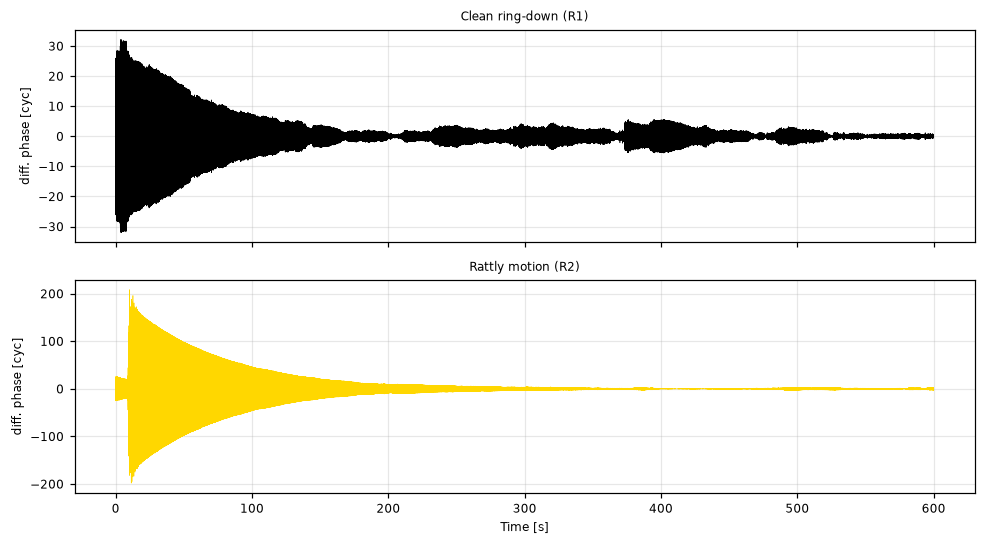

clean : std 5.56 cyc, p2p 64.3 cyc
rattly: std 29.73 cyc, p2p 406.5 cyc


In [3]:
CLEAN = "FM1Day09_AirReleasedOPD_SHIMMED_FLIGHTTORQUED_R1_20260629_130407.zip"
RATTLY = "FM1Day09_AirReleasedOPD_NOSHIMS_FLIGHTTORQUED_R2_20260629_120742.zip"
OUTLIER = "FM1Day09_AirReleasedOPD_SHIMMED_FLIGHTTORQUED_R2_20260629_130406.zip"


def load_diff(fname):
    d = load_phasemeter(str(DATA / fname))
    _, phi = d.differential(cfg.channels)
    return d, phi


dclean, phiclean = load_diff(CLEAN)
drat, phirat = load_diff(RATTLY)

fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(dclean.t, phiclean - phiclean.mean(), lw=0.4, color="C0")
ax[0].set(ylabel="diff. phase [cyc]", title="Clean ring-down (R1)")
ax[1].plot(drat.t, phirat - phirat.mean(), lw=0.4, color="C3")
ax[1].set(xlabel="Time [s]", ylabel="diff. phase [cyc]",
          title="Rattly motion (R2)")
fig.tight_layout()
plt.show()
print(f"clean : std {np.std(phiclean):.2f} cyc, p2p {np.ptp(phiclean):.1f} cyc")
print(f"rattly: std {np.std(phirat):.2f} cyc, p2p {np.ptp(phirat):.1f} cyc")

## 3. The near-tone floor is what matters

Zooming the differential-phase spectrum onto the demodulation band shows the
rattly system has a much higher broadband floor right next to the tone.

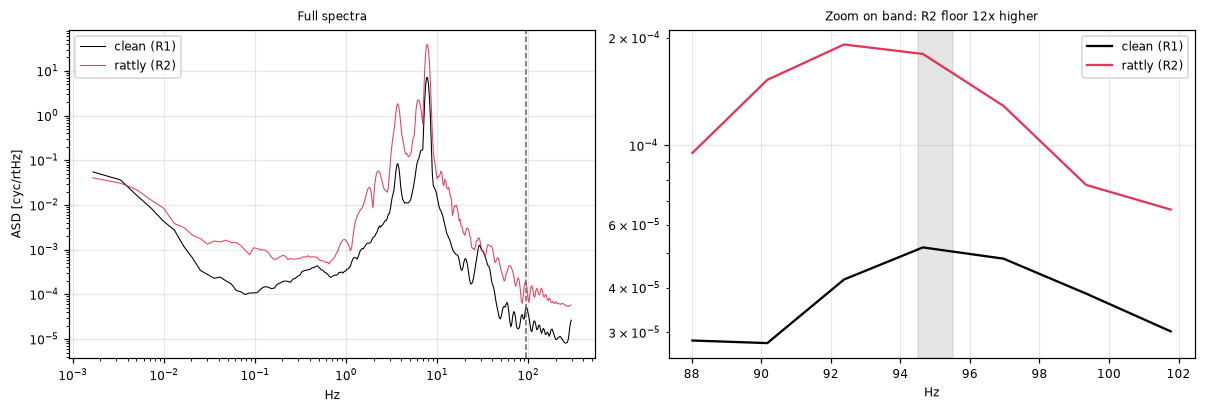

near-tone floor  clean 1.35e-05  rattly 1.62e-04  ratio 12x


In [4]:
def band_floor(phi, fs, f0=FMOD, lo=0.6, hi=1.5):
    x = phi - np.mean(phi)
    win = np.hanning(x.size)
    f = np.fft.rfftfreq(x.size, 1 / fs)
    X = np.fft.rfft(x * win)
    enbw = fs * np.sum(win**2) / np.sum(win)**2
    asd = np.sqrt((np.abs(X)**2) / (np.sum(win)**2 * enbw) * 2.0)
    m = (((f >= f0-hi) & (f <= f0-lo)) | ((f >= f0+lo) & (f <= f0+hi)))
    return float(np.sqrt(np.mean(asd[m]**2)))


sc = compute_spectrum(phiclean - phiclean.mean(), dclean.fs, win="kaiser", olap="default")
sr = compute_spectrum(phirat - phirat.mean(), drat.fs, win="kaiser", olap="default")
fc, fr = band_floor(phiclean, dclean.fs), band_floor(phirat, drat.fs)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].loglog(sc.f, sc.asd, lw=0.7, label="clean (R1)")
ax[0].loglog(sr.f, sr.asd, lw=0.7, alpha=0.8, label="rattly (R2)")
ax[0].axvline(FMOD, color="0.4", ls="--", lw=1)
ax[0].set(xlabel="Hz", ylabel="ASD [cyc/rtHz]", title="Full spectra")
ax[0].legend()
selc = (sc.f > FMOD-8) & (sc.f < FMOD+8)
selr = (sr.f > FMOD-8) & (sr.f < FMOD+8)
ax[1].semilogy(sc.f[selc], sc.asd[selc], label="clean (R1)")
ax[1].semilogy(sr.f[selr], sr.asd[selr], alpha=0.85, label="rattly (R2)")
ax[1].axvspan(FMOD-0.5, FMOD+0.5, color="0.6", alpha=0.25)
ax[1].set(xlabel="Hz", title=f"Zoom on band: R2 floor {fr/fc:.0f}x higher")
ax[1].legend()
fig.tight_layout()
plt.show()
print(f"near-tone floor  clean {fc:.2e}  rattly {fr:.2e}  ratio {fr/fc:.0f}x")

## 4. How the standard estimator is fooled (rattly record)

`|z(t)|` is inflated by the in-band motion power. The incoherent RMS sums that
power as signal; the robust coherent projection rejects the zero-mean part; the
near-tone floor shows the noise is comparable to the tone.

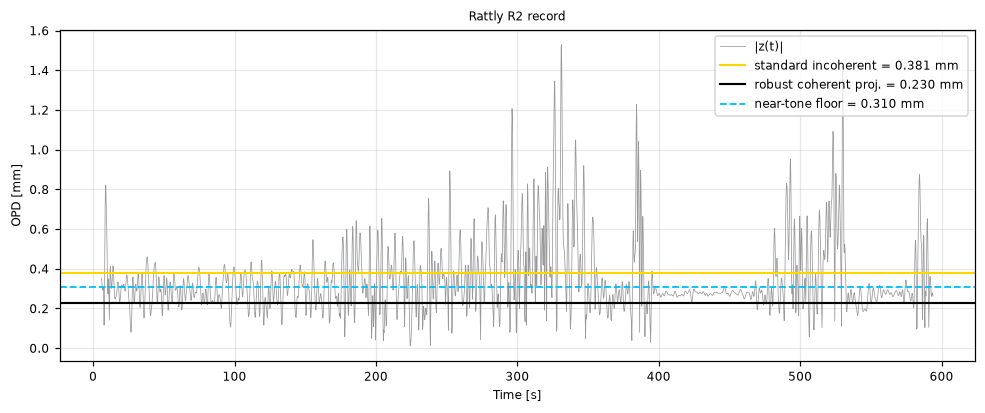

In [5]:
f0 = refine_frequency(phirat, drat.fs, FMOD)
dm = demodulate(phirat, drat.fs, f0)
rb = demodulate_robust(phirat, drat.fs, f0)
opd_t = phase_cycles_to_opd(np.abs(dm.z), DNU) * 1e3

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(dm.t, opd_t, lw=0.5, color="0.6", label="|z(t)|")
ax.axhline(to_mm(dm.amplitude), color="C3", lw=1.4,
           label=f"standard incoherent = {to_mm(dm.amplitude):.3f} mm")
ax.axhline(to_mm(rb.amp_robust), color="C0", lw=1.4,
           label=f"robust coherent proj. = {to_mm(rb.amp_robust):.3f} mm")
ax.axhline(to_mm(rb.near_tone_floor), color="C2", lw=1.2, ls="--",
           label=f"near-tone floor = {to_mm(rb.near_tone_floor):.3f} mm")
ax.set(xlabel="Time [s]", ylabel="OPD [mm]", title="Rattly R2 record")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 5. Before/after on every Day09 released file

`estimate_opd_robust` returns both the standard OPD and the robust OPD, plus the
absolute near-tone floor, the reliability (`OPD / floor`), and the test-mass
motion RMS. Reliability below ~3 flags a contaminated, untrustworthy record.

In [6]:
FILES = [
    ("R1", "NOSHIMS", "FM1Day09_AirReleasedOPD_NOSHIMS_R1_20260629_113414.zip"),
    ("R1", "NOSHIMS+torqued", "FM1Day09_AirReleasedOPD_NOSHIMS_FLIGHTTORQUED_R1_20260629_120744.zip"),
    ("R1", "shimmed+torqued", "FM1Day09_AirReleasedOPD_SHIMMED_FLIGHTTORQUED_R1_20260629_130407.zip"),
    ("R1", "shimmed+torqued (vac)", "FM1Day09_VacuumReleasedOPD_SHIMMED_FLIGHTTORQUED_R1_20260629_140109.zip"),
    ("R2", "NOSHIMS", "FM1Day09_AirReleasedOPD_NOSHIMS_R2_20260629_113415.zip"),
    ("R2", "NOSHIMS+torqued", "FM1Day09_AirReleasedOPD_NOSHIMS_FLIGHTTORQUED_R2_20260629_120742.zip"),
    ("R2", "shimmed+torqued", "FM1Day09_AirReleasedOPD_SHIMMED_FLIGHTTORQUED_R2_20260629_130406.zip"),
    ("R2", "shimmed+torqued (vac)", "FM1Day09_VacuumReleasedOPD_SHIMMED_FLIGHTTORQUED_R2_20260629_140110.zip"),
]

recs = []
for sysname, cfgname, fname in FILES:
    r = estimate_opd_robust(str(DATA / fname), config=cfg, mod_freq=FMOD)
    recs.append({
        "sys": sysname, "config": cfgname,
        "OPD_std_mm": r.opd_standard * 1e3, "std_mode": r.standard_mode,
        "OPD_robust_mm": r.opd_robust * 1e3,
        "floor_um": r.near_tone_floor * 1e6,
        "reliability": r.reliability,
        "motion_um": r.motion_rms * 1e6,
        "flag": "" if r.reliability >= 3 else "LOW",
    })

df = pd.DataFrame(recs)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
df

,sys,config,OPD_std_mm,std_mode,OPD_robust_mm,floor_um,reliability,motion_um,flag
0,R1,NOSHIMS,0.241,coherent,0.206,14.391,14.342,1.983,
1,R1,NOSHIMS+torqued,0.127,coherent,0.115,36.973,3.119,13.157,
2,R1,shimmed+torqued,0.288,coherent,0.291,31.392,9.261,8.670,
3,R1,shimmed+torqued (vac),0.089,coherent,0.080,24.532,3.275,21.592,
4,R2,NOSHIMS,0.261,incoherent,0.459,132.260,3.470,2.957,
5,R2,NOSHIMS+torqued,0.381,incoherent,0.230,309.810,0.742,46.086,LOW
6,R2,shimmed+torqued,0.840,incoherent,0.883,407.717,2.166,4.721,LOW
7,R2,shimmed+torqued (vac),0.271,incoherent,0.209,303.744,0.689,9.041,LOW


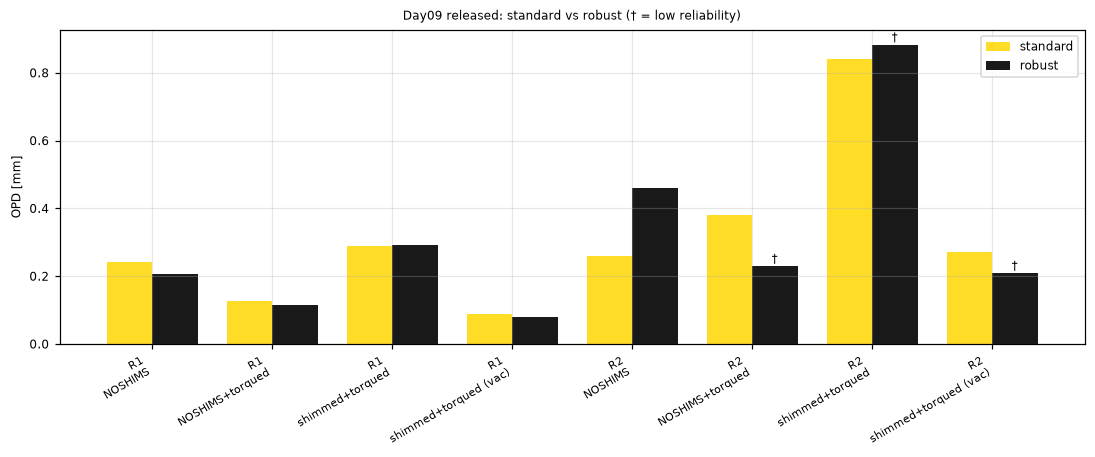

R1 floors (um): [14.0, 37.0, 31.0, 25.0]
R2 floors (um): [132.0, 310.0, 408.0, 304.0]


In [7]:
x = np.arange(len(df))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(x - w/2, df["OPD_std_mm"], w, color="C3", alpha=0.85, label="standard")
ax.bar(x + w/2, df["OPD_robust_mm"], w, color="C0", alpha=0.9, label="robust")
for i, row in df.iterrows():
    if row["flag"]:
        ax.annotate("$\\dagger$", (i + w/2, row["OPD_robust_mm"]),
                    textcoords="offset points", xytext=(0, 2), ha="center")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n{c}" for s, c in zip(df["sys"], df["config"])],
                   fontsize=7, rotation=30, ha="right")
ax.set_ylabel("OPD [mm]")
ax.set_title("Day09 released: standard vs robust ($\\dagger$ = low reliability)")
ax.legend()
fig.tight_layout()
plt.show()

print("R1 floors (um):", df[df.sys == "R1"].floor_um.round(0).tolist())
print("R2 floors (um):", df[df.sys == "R2"].floor_um.round(0).tolist())

## 6. Validation with a known OPD

Real records have no ground truth, so we inject a known `OPD0`, add a large
low-frequency motion plus a controlled random-phase narrowband contamination
centered on `f_mod` (broadband motion power landing in-band), and sweep the
contamination level. The robust estimator should stay on the truth while the
standard one climbs.

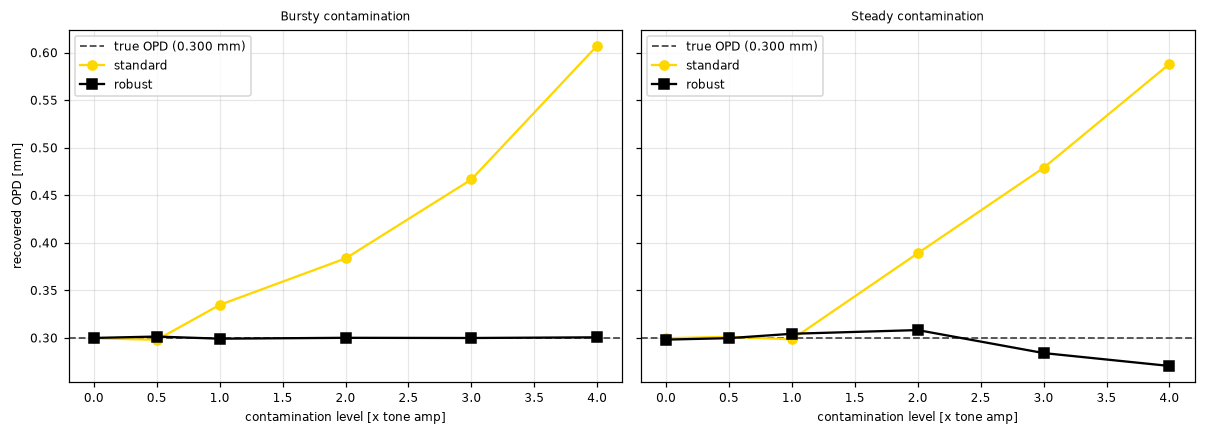

at 4x tone: standard = 0.607 / 0.588 mm (bursty/steady)
            robust   = 0.301 / 0.270 mm   (truth 0.300)


In [8]:
FS = 596.04644775
rng = np.random.default_rng(11)
OPD0 = 0.30e-3
A0 = opd_to_phase_cycles(OPD0, DNU)
n = int(300 * FS)
tt = np.arange(n) / FS


def lf_motion(t, rms=4.0):
    comps = [(1, 0.11, 0.4), (0.6, 0.4, 1.1), (0.3, 1.2, 2.0),
             (0.2, 3.0, 0.7), (0.1, 7.7, 1.3)]
    x = sum(a * np.sin(2*np.pi*f*t + p) for a, f, p in comps)
    return x / np.std(x) * rms


def inband(t, fs, f0, level, bursty):
    c = rng.standard_normal(t.size) + 1j*rng.standard_normal(t.size)
    b, a = butter(2, 3.0/(fs/2)); c = filtfilt(b, a, c)
    if bursty:
        env = np.zeros(t.size)
        for c0 in np.linspace(20, t[-1]-20, 4):
            env += np.exp(-0.5*((t-c0)/7.0)**2)
        env = np.clip(env, 0, 1)
    else:
        env = np.ones(t.size)
    c *= env
    c = c / np.sqrt(np.mean(np.abs(c)**2)) * level
    return (c * np.exp(1j*2*np.pi*f0*t)).real


levels = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0])
lf = lf_motion(tt)
res = {"bursty": {"std": [], "rob": []}, "steady": {"std": [], "rob": []}}
for bursty, key in [(True, "bursty"), (False, "steady")]:
    for lv in levels:
        phi = (A0*np.cos(2*np.pi*FMOD*tt + 0.7) + lf
               + (inband(tt, FS, FMOD, lv*A0, bursty) if lv > 0 else 0.0)
               + 1e-4*rng.standard_normal(n))
        res[key]["std"].append(to_mm(demodulate(phi, FS, FMOD).amplitude))
        res[key]["rob"].append(to_mm(demodulate_robust(phi, FS, FMOD).amp_robust))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, key, ttl in zip(axes, ["bursty", "steady"],
                        ["Bursty contamination", "Steady contamination"]):
    ax.axhline(OPD0*1e3, color="0.3", ls="--", lw=1.2, label="true OPD (0.300 mm)")
    ax.plot(levels, res[key]["std"], "o-", color="C3", label="standard")
    ax.plot(levels, res[key]["rob"], "s-", color="C0", label="robust")
    ax.set(xlabel="contamination level [x tone amp]", title=ttl)
    ax.legend()
axes[0].set_ylabel("recovered OPD [mm]")
fig.tight_layout()
plt.show()

i4 = int(np.where(levels == 4.0)[0][0])
print(f"at 4x tone: standard = {res['bursty']['std'][i4]:.3f} / "
      f"{res['steady']['std'][i4]:.3f} mm (bursty/steady)")
print(f"            robust   = {res['bursty']['rob'][i4]:.3f} / "
      f"{res['steady']['rob'][i4]:.3f} mm   (truth 0.300)")

## 7. Bonus: the test-mass motion (force-sensing signal)

The same low-frequency phase whose in-band tail is dangerous is a clean,
high-resolution readout of the released mass, `delta(t) = lambda * phi_LF(t)`,
returned by the robust pipeline.

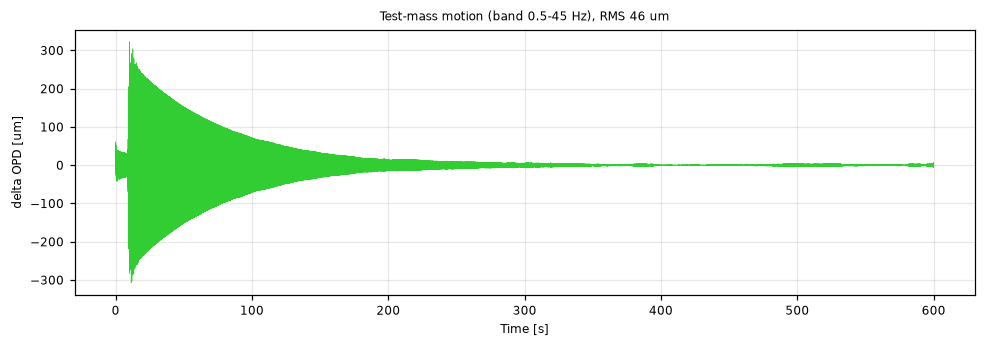

In [9]:
r = estimate_opd_robust(str(DATA / RATTLY), config=cfg, mod_freq=FMOD)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(r.motion_t, r.motion * 1e6, lw=0.4, color="C4")
ax.set(xlabel="Time [s]", ylabel="delta OPD [um]",
       title=f"Test-mass motion (band {r.motion_band[0]:.1f}-{r.motion_band[1]:.0f} Hz), "
             f"RMS {r.motion_rms*1e6:.0f} um")
fig.tight_layout()
plt.show()

## Takeaways

- A rattly (impulsive) test mass injects broadband power into the demodulation
  band, amplified by `nu0 / delta_nu_pk ~ 1e6`. A clean ring-down, however
  large, does not.
- The standard incoherent estimator sums this in-band power as if it were
  signal and biases the OPD high (up to ~2x on synthetic data).
- The robust estimator (matched-filter coherent projection + adjacent-bin floor
  + gating) recovers the true OPD to within ~10% on synthetic data, and reports
  an absolute contamination floor and reliability flag so corrupted real records
  are identified rather than trusted.
- Best fix is upstream: damp the mass and avoid impulsive re-excitation before
  acquiring. Report the recovered motion as the force-sensing signal.